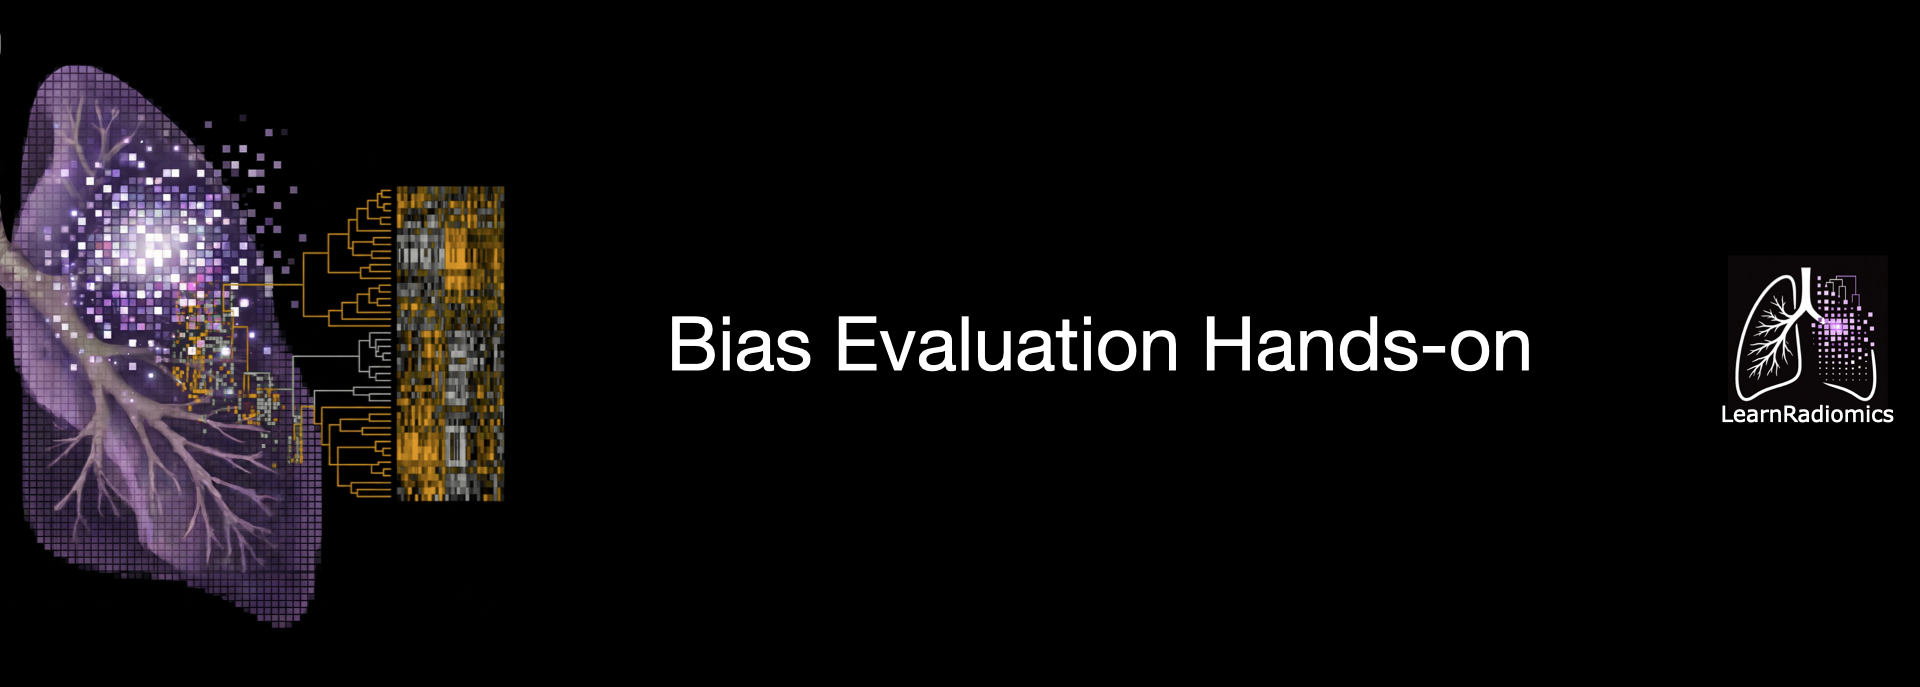

### General Libraries

In [ ]:
## libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotnine import*
from collections import Counter
import requests
import json
import sklearn.metrics as mt
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay

pd.options.display.max_rows = None
pd.options.display.max_columns = None

import warnings
warnings.filterwarnings('ignore')

In [ ]:
def discretizar_edades(edades, bins=0):
    edades = np.array(edades)

    # Definimos los cortes automáticos si bins es un entero
    if isinstance(bins, int):
        categorias = pd.cut(edades, bins=bins)
    else:
        # Si se pasan cortes manuales
        categorias = pd.cut(edades, bins=bins, include_lowest=True)

    return categorias.astype(str)


### Data loading

In [ ]:
### df with clinical data, y_true and predictions

data = pd.read_excel('https://raw.githubusercontent.com/learnradiomics/AI_tools_evaluation/main/df_test_subgroup_analysis.xlsx')
data.shape

In [ ]:
data.head()

### Exploratory Data Analysis

In [ ]:
(ggplot(data) +
 aes(x="Age") +
 geom_histogram(fill='mediumorchid', color='black', alpha=0.7)+
 theme_bw()

 )

In [ ]:
(
    ggplot(data, aes(x="Manufacturer_DICOM"))
    + geom_bar(fill='dodgerblue', alpha=0.8)
    + theme_bw()
    + labs(
        title="Manufacturer Distribution",
        x="DICOM Manufacturer",
        y="Number of Studies"
    )
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [ ]:

(
    ggplot(data, aes(x="PatientSex_DICOM"))
    + geom_bar(fill='darkorchid', color='gray', alpha=0.8)
    + theme_bw()
    + labs(
        title="Sex distribution",
        x="Sex",
        y="Number of Studies"

    )
)


In [ ]:
### Low quality studies

Counter(data['calidad deficiente'])

In [ ]:
print(classification_report(data.Label, data.Prediccion, target_names = ['normal', 'patológico']))

In [ ]:
### ROC AUC: All Patients
plt.figure(figsize=(12,10))

fpr_test, tpr_test, _ = mt.roc_curve(data.Label, data.Prediccion, pos_label=1)
auc_test = round(mt.auc(fpr_test,tpr_test),3)
plt.plot(fpr_test, tpr_test,label="AUC data test, AUC=" + str(auc_test), color='darkorchid')

plt.plot([0,1], [0,1],color='gray', lw=2, linestyle="--")

plt.title('ROC Curves')
plt.legend(fontsize=14)
plt.show()

In [ ]:

### ROC AUC: Low Quality Studies

plt.figure(figsize=(12,10))

fpr_test, tpr_test, _ = mt.roc_curve(data[data['calidad deficiente'] == 1].Label ,data[data['calidad deficiente'] == 1].Prediccion, pos_label=1)
auc_test = round(mt.auc(fpr_test,tpr_test),3)
plt.plot(fpr_test, tpr_test,label="AUC data test, AUC=" + str(auc_test), color='dodgerblue')

plt.plot([0,1], [0,1],color='gray', lw=2, linestyle="--")

plt.title('ROC Curves in Low Quality Studies')
plt.legend(fontsize=14)
plt.show()

In [ ]:

### ROC AUC: High Quality Studies

plt.figure(figsize=(12,10))

fpr_test, tpr_test, _ = mt.roc_curve(data[data['calidad deficiente'] == 0].Label ,data[data['calidad deficiente'] == 0].Prediccion, pos_label=1)
auc_test = round(mt.auc(fpr_test,tpr_test),3)
plt.plot(fpr_test, tpr_test,label="AUC data test, AUC=" + str(auc_test), color='orange')

plt.plot([0,1], [0,1],color='gray', lw=2, linestyle="--")

plt.title('ROC Curves in Regular Quality Studies')
plt.legend(fontsize=14)
plt.show()

In [ ]:
## Confusion Matrix

cm = confusion_matrix(data.Label, data.Prediccion)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'abnormal'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### Data Preprocessing

In [ ]:
## Age Discretization

df_test_evaluacion = data.copy()

print("Edad mínima:", df_test_evaluacion.Age.min())
print("Edad máxima:", df_test_evaluacion.Age.max())

bins_cortes = [0.1,15,30,50,70,80,90,115]
categoria_edades = discretizar_edades(df_test_evaluacion.Age, bins=bins_cortes)
df_test_evaluacion ['rango de edad'] = categoria_edades

vector_edad_corregido = np.where(df_test_evaluacion['rango de edad'] == '(70.0, 80.0]', '70 - 80 years', df_test_evaluacion['rango de edad'])
vector_edad_corregido = np.where(vector_edad_corregido== '(90.0, 115.0]', '90 - 115 years', vector_edad_corregido)
vector_edad_corregido = np.where(vector_edad_corregido== '(50.0, 70.0]', '50 - 70 years', vector_edad_corregido)
vector_edad_corregido = np.where(vector_edad_corregido== '(80.0, 90.0]', '80 - 90 years', vector_edad_corregido)
vector_edad_corregido = np.where(vector_edad_corregido== '(15.0, 30.0]', '15 - 30 years', vector_edad_corregido)
vector_edad_corregido = np.where(vector_edad_corregido== '(30.0, 50.0]', '30 - 50 years', vector_edad_corregido)
vector_edad_corregido = np.where(vector_edad_corregido== '(0.099, 15.0]','0 - 15 years]', vector_edad_corregido)
df_test_evaluacion ['rango de edad']  = vector_edad_corregido

#### SubGroup Analysis

In [ ]:
variables_evaluar = ['PatientSex_DICOM', 'Manufacturer_DICOM', 'calidad deficiente']

dic_results = {}

for rango in df_test_evaluacion['rango de edad'].unique():
    dic_results[rango] = {}
    df_temp = df_test_evaluacion[df_test_evaluacion['rango de edad'] == rango]
    for var in variables_evaluar:
        dic_results[rango][var] = {}
        for i in range(len(df_temp[var].unique())):
            cat = df_test_evaluacion[var].unique()[i]
            df_temp_auc = df_temp[df_temp[var] == cat]
            fpr, tpr, _ = mt.roc_curve(df_temp_auc.Label,df_temp_auc.Prediccion, pos_label=1)
            auc = round(mt.auc(fpr,tpr),3)
            dic_results[rango][var][cat] = auc

vector_rangos = []
vector_auc = []
vector_caracteristica = []
vector_subcaracteristica = []

for rango in dic_results.keys():
    for caracteristica in dic_results[rango].keys():
        for subcaracteristica in dic_results[rango][caracteristica].keys():
            vector_rangos.append(rango)
            vector_auc.append(dic_results[rango][caracteristica][subcaracteristica])
            vector_caracteristica.append(caracteristica)
            vector_subcaracteristica.append(subcaracteristica)

df_total_test = pd.DataFrame()
df_total_test['rango de edad'] = vector_rangos
df_total_test['AUC'] = vector_auc
df_total_test['caracteristica'] = vector_caracteristica
df_total_test['clase'] = vector_subcaracteristica

vector_clase_corregido = np.where(df_total_test.clase == 'F', 'PatientSex: Female', df_total_test.clase)
vector_clase_corregido = np.where(vector_clase_corregido == 'M', 'PatientSex: Male', vector_clase_corregido)
vector_clase_corregido = np.where(vector_clase_corregido == 'ImagingDynamicsCompanyLtd', 'Brand: ImagingDynamicsCompanyLtd', vector_clase_corregido)
vector_clase_corregido = np.where(vector_clase_corregido == 'PhilipsMedicalSystems', 'Brand: PhilipsMedicalSystems', vector_clase_corregido)
vector_clase_corregido = np.where(vector_clase_corregido == 0.0, 'Calidad técnica adecuada', vector_clase_corregido)
vector_clase_corregido = np.where(vector_clase_corregido == 1.0, 'Calidad técnica deficiente', vector_clase_corregido)

df_total_test['categoria'] = vector_clase_corregido

(
ggplot(df_total_test[df_total_test.caracteristica !='calidad deficiente'])+
    aes(x='rango de edad', y='AUC', fill= 'categoria') +
    geom_col(stat ='identity', position='dodge', alpha=0.8) +
    theme_bw() +
    scale_y_continuous(breaks = np.arange(0,105, 5) /100)+
    scale_fill_manual( values=['dodgerblue','lightskyblue','blueviolet','sienna'])+
    labs(title='Subgroup Analysys', x='Age Range')+
    theme(figure_size=(14,6))

)